# Merging comparison

The second experiment focus on determining which merging strategy is the best one (and in which case).\
The three merging strategy considered are : **basic**, **binary**, **heap**.

Given **k** streams, the first algorithm has a time complexity of $O(kn)$, while the other twos have a time complexity of $O(nlog(k))$.

The various implementation are mostly based on **Wikipedia, online forum and public github repositories**, at which in addiction there is a personal researcher based **also** on LLM.

The experiment is based mostly on **MPI** level (since **k** literally is the number of MPI ranks). The number of **OMP threads** are fixed to 1. The number of **MPI ranks** increase exponentially from **4** to **64**.

Here is reported the common configuration for all the runs:

* **n_bits** : $64$
* **n_keys** : $5\times10^7$
* **n_threads** : $1$
* **keys_distribution** : uniform
* **sorting_strategy** : radix

Experiments were executed on [**Orfeo, partition GENOA**](https://orfeo-doc.areasciencepark.it/HPC/computational-resources/).

The key metric here is **time_merging_seconds**.

In [33]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [34]:
results = pd.read_csv("../Parallel/results/merging_comparison.csv")
results = results[
    ["n_bits", "n_key", "n_ranks", "merging_strategy", "time_merge_seconds"]
]
results.head()

,n_bits,n_key,n_ranks,merging_strategy,time_merge_seconds
0,32,50000000,4,basic,0.185568
1,32,50000000,4,bin,0.179349
2,32,50000000,4,heap,0.226441
3,32,50000000,8,basic,0.132381
4,32,50000000,8,bin,0.139034


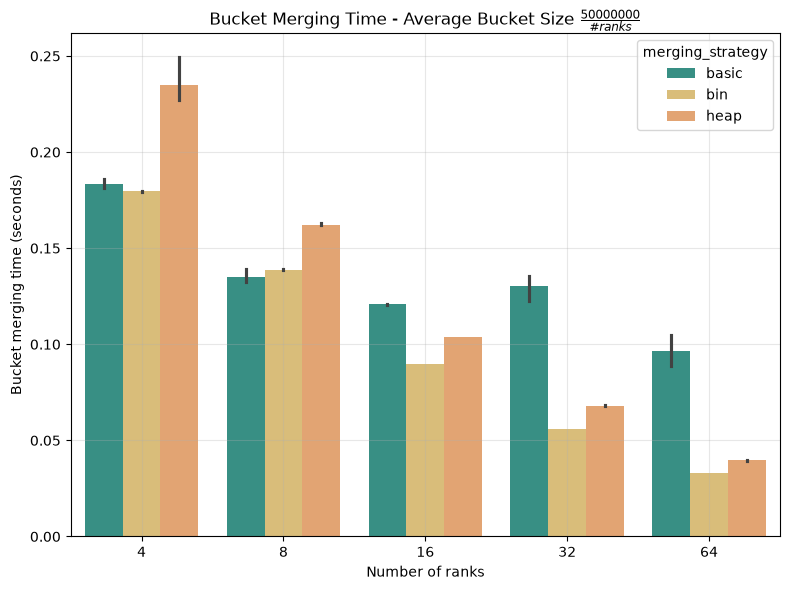

In [35]:
custom_palette = {
    "basic" : "#2A9D8F",
    "bin" : "#e9c46a",
    "heap" : "#F4A261"
}

plt.figure(figsize=(8, 6))

sns.barplot(
    data=results,
    x="n_ranks",
    y="time_merge_seconds",
    hue="merging_strategy",
    palette=custom_palette
)

plt.xlabel("Number of ranks")
plt.ylabel("Bucket merging time (seconds)")
plt.title(r"Bucket Merging Time - Average Bucket Size $\frac{50000000}{ \# ranks}$")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()